In [1]:
import os, sys, subprocess

print("Python:", sys.executable)
print("Working directory:", os.getcwd())

subprocess.check_call([sys.executable, "-m", "pip", "show", "-f", "hirank"])

Python: /home/asmi28/anaconda3/envs/steering/bin/python
Working directory: /home/asmi28/Downloads/hirank-main/doc
Name: hirank
Version: 0.1.1
Summary: High-dimensional rank-based outlier detection using reverse k-NN density estimation
Home-page: https://github.com/TutteInstitute/hirank
Author: Aaron Smith
Author-email: John Healy <jchealy@gmail.com>
License: MIT
Location: /home/asmi28/anaconda3/envs/steering/lib/python3.13/site-packages
Editable project location: /home/asmi28/Downloads/hirank-main
Requires: joblib, numba, numpy, pynndescent, scikit-learn, scipy
Required-by: 
Files:
  __editable__.hirank-0.1.1.pth
  __editable___hirank_0_1_1_finder.py
  __pycache__/__editable___hirank_0_1_1_finder.cpython-313.pyc
  hirank-0.1.1.dist-info/INSTALLER
  hirank-0.1.1.dist-info/METADATA
  hirank-0.1.1.dist-info/RECORD
  hirank-0.1.1.dist-info/REQUESTED
  hirank-0.1.1.dist-info/WHEEL
  hirank-0.1.1.dist-info/direct_url.json
  hirank-0.1.1.dist-info/licenses/LICENSE
  hirank-0.1.1.dist-info/top

0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from hirank import RankOD
from hirank.bootstrap_rankod import BootstrapRankOD
from sklearn.base import clone

import time
import warnings

In [3]:
def ood_train_test_split(X, y, hold_out_label, rng=np.random.default_rng()):
    # Split into normal and ood sets
    ood_mask = y == hold_out_label

    X_inlier = X[~ood_mask]
    y_inlier = y[~ood_mask]
    X_outlier = X[ood_mask]
    y_outlier = y[ood_mask]

    inlier_test_mask = np.zeros(X_inlier.shape[0], dtype="bool")
    inlier_test_mask[rng.choice(np.arange(len(inlier_test_mask)), size=np.sum(ood_mask), replace=False)] = True

    X_train = X_inlier[~inlier_test_mask]
    y_train = y_inlier[~inlier_test_mask]
    X_test = np.vstack([X_outlier, X_inlier[inlier_test_mask]])
    y_test = np.concatenate([y_outlier, y_inlier[inlier_test_mask]])
    y_ood = y_test == hold_out_label

    split = {"x_train":X_train, "x_test":X_test, "y_test":y_test, "y_ood":y_ood, "hold_out_label":hold_out_label}
    return split

# Global Parameters

In [4]:
n_samples = 10000

# Load Data

## MNIST

In [5]:
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# Take a subset for faster computation
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

Loading MNIST dataset...
✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(969), 1: np.int64(1161), 2: np.int64(964), 3: np.int64(1011), 4: np.int64(944), 5: np.int64(901), 6: np.int64(1004), 7: np.int64(1046), 8: np.int64(986), 9: np.int64(1014)}


In [6]:
mnist_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in mnist_splits:
    split["dataset"] = "mnist"
len(mnist_splits)

10

## Fashion MNSIT

In [7]:
fashion = fetch_openml('Fashion-MNIST', version=1, parser='auto')
X = fashion.data.to_numpy()
y = fashion.target.astype(int).to_numpy()

# Take a subset for faster computation
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(1004), 1: np.int64(1024), 2: np.int64(1017), 3: np.int64(985), 4: np.int64(999), 5: np.int64(1012), 6: np.int64(982), 7: np.int64(985), 8: np.int64(1004), 9: np.int64(988)}


In [8]:
fashion_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in fashion_splits:
    split["dataset"] = "fashion"
len(fashion_splits)

10

## Aggregate all splits

In [9]:
splits = mnist_splits + fashion_splits
len(splits)

20

# Define Methods

In [10]:
rank_l2_invsqrt_local = RankOD(
    mode = "rank",
    calibration = "local",
    max_rank = 50,
    random_state = 42,
)

rank_l2_invsqrt_global = RankOD(
    mode = "rank",
    calibration = "global",
    max_rank = 50,
    random_state = 42,
)

rank_l2_linear_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "linear",
    max_rank = 50,
    random_state = 42,
)

rank_l2_linear_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "linear",
    max_rank = 50,
    random_state = 42,
)

rank_l2_inverselog_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "inverse_log",
    max_rank = 50,
    random_state = 42,
)

rank_l2_inverselog_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "inverse_log",
    max_rank = 50,
    random_state = 42,
)

rank_l2_invsqrt_local = RankOD(
    mode = "rank",
    calibration = "local",
    max_rank = 50,
    random_state = 42,
)

rank_cos_invsqrt_global = RankOD(
    mode = "rank",
    calibration = "global",
    max_rank = 50,
    random_state = 42,
)

rank_cos_linear_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "linear",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

rank_cos_linear_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "linear",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

rank_cos_inverselog_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "inverse_log",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

rank_cos_inverselog_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "inverse_log",
    metric = "cosine",
    max_rank = 50,
    random_state = 42,
)

sun_global = RankOD(
    mode = "sun",
    calibration = "raw",
    random_state = 42,
)

sun_local = RankOD(
    mode = "rank",
    calibration = "global",
    random_state = 42,
)

lof = LocalOutlierFactor(
    novelty=True,
)

iso = IsolationForest(
    random_state = 42,
)

def _make_bootstrap_method(method, sample_rate):
    m_function = lambda n: int(sample_rate * n)
    if isinstance(method, RankOD):
        return BootstrapRankOD(
            n_bootstrap_sample = 5,
            m_function = m_function,
            **method.get_params(),
        )

    bootstrap_method = BootstrapRankOD(
        n_bootstrap_sample = 5,
        m_function = m_function,
    )
    bootstrap_method.detectors = [
        clone(method) for _ in range(bootstrap_method.n_bootstrap_sample)
    ]
    return bootstrap_method

rank_l2_invsqrt_local_bs_75 = _make_bootstrap_method(
    rank_l2_invsqrt_local,
    0.75,
)
rank_l2_invsqrt_local_bs_90 = _make_bootstrap_method(
    rank_l2_invsqrt_local,
    0.90,
)
rank_l2_invsqrt_global_bs_75 = _make_bootstrap_method(
    rank_l2_invsqrt_global,
    0.75,
)
rank_l2_invsqrt_global_bs_90 = _make_bootstrap_method(
    rank_l2_invsqrt_global,
    0.90,
)
rank_l2_linear_local_bs_75 = _make_bootstrap_method(
    rank_l2_linear_local,
    0.75,
)
rank_l2_linear_local_bs_90 = _make_bootstrap_method(
    rank_l2_linear_local,
    0.90,
)
rank_l2_linear_global_bs_75 = _make_bootstrap_method(
    rank_l2_linear_global,
    0.75,
)
rank_l2_linear_global_bs_90 = _make_bootstrap_method(
    rank_l2_linear_global,
    0.90,
)
rank_cos_invsqrt_global_bs_75 = _make_bootstrap_method(
    rank_cos_invsqrt_global,
    0.75,
)
rank_cos_invsqrt_global_bs_90 = _make_bootstrap_method(
    rank_cos_invsqrt_global,
    0.90,
)
rank_cos_linear_local_bs_75 = _make_bootstrap_method(
    rank_cos_linear_local,
    0.75,
)
rank_cos_linear_local_bs_90 = _make_bootstrap_method(
    rank_cos_linear_local,
    0.90,
)
rank_cos_linear_global_bs_75 = _make_bootstrap_method(
    rank_cos_linear_global,
    0.75,
)
rank_cos_linear_global_bs_90 = _make_bootstrap_method(
    rank_cos_linear_global,
    0.90,
)
sun_global_bs_75 = _make_bootstrap_method(
    sun_global,
    0.75,
)
sun_global_bs_90 = _make_bootstrap_method(
    sun_global,
    0.90,
)
sun_local_bs_75 = _make_bootstrap_method(
    sun_local,
    0.75,
)
sun_local_bs_90 = _make_bootstrap_method(
    sun_local,
    0.90,
)
lof_bs_75 = _make_bootstrap_method(
    lof,
    0.75,
)
lof_bs_90 = _make_bootstrap_method(
    lof,
    0.90,
)
iso_bs_75 = _make_bootstrap_method(
    iso,
    0.75,
)
iso_bs_90 = _make_bootstrap_method(
    iso,
    0.90,
)

methods = [
    rank_l2_invsqrt_local,
    rank_l2_invsqrt_global,
    rank_l2_linear_local,
    rank_l2_linear_global,
    rank_l2_invsqrt_local,
    rank_cos_invsqrt_global,
    rank_cos_linear_local,
    rank_cos_linear_global,
    sun_global,
    sun_local,
    lof,
    iso,
    rank_l2_invsqrt_local_bs_75,
    rank_l2_invsqrt_local_bs_90,
    rank_l2_invsqrt_global_bs_75,
    rank_l2_invsqrt_global_bs_90,
    rank_l2_linear_local_bs_75,
    rank_l2_linear_local_bs_90,
    rank_l2_linear_global_bs_75,
    rank_l2_linear_global_bs_90,
    rank_l2_invsqrt_local_bs_75,
    rank_l2_invsqrt_local_bs_90,
    rank_cos_invsqrt_global_bs_75,
    rank_cos_invsqrt_global_bs_90,
    rank_cos_linear_local_bs_75,
    rank_cos_linear_local_bs_90,
    rank_cos_linear_global_bs_75,
    rank_cos_linear_global_bs_90,
    sun_global_bs_75,
    sun_global_bs_90,
    sun_local_bs_75,
    sun_local_bs_90,
    lof_bs_75,
    lof_bs_90,
    iso_bs_75,
    iso_bs_90,
]

method_names = [
    'rank_l2_invsqrt_local',
    'rank_l2_invsqrt_global',
    'rank_l2_linear_local',
    'rank_l2_linear_global',
    'rank_l2_invsqrt_local',
    'rank_cos_invsqrt_global',
    'rank_cos_linear_local',
    'rank_cos_linear_global',
    'sun_global',
    'sun_local',
    'lof',
    'iso',
    'rank_l2_invsqrt_local_bs_75',
    'rank_l2_invsqrt_local_bs_90',
    'rank_l2_invsqrt_global_bs_75',
    'rank_l2_invsqrt_global_bs_90',
    'rank_l2_linear_local_bs_75',
    'rank_l2_linear_local_bs_90',
    'rank_l2_linear_global_bs_75',
    'rank_l2_linear_global_bs_90',
    'rank_l2_invsqrt_local_bs_75',
    'rank_l2_invsqrt_local_bs_90',
    'rank_cos_invsqrt_global_bs_75',
    'rank_cos_invsqrt_global_bs_90',
    'rank_cos_linear_local_bs_75',
    'rank_cos_linear_local_bs_90',
    'rank_cos_linear_global_bs_75',
    'rank_cos_linear_global_bs_90',
    'sun_global_bs_75',
    'sun_global_bs_90',
    'sun_local_bs_75',
    'sun_local_bs_90',
    'lof_bs_75',
    'lof_bs_90',
    'iso_bs_75',
    'iso_bs_90',
]

# Run Tests

In [11]:
print(f"Testing {len(methods)} methods on {len(splits)} train/test splits.")
results = []
for split in splits:
    print(f"Testing dataset {split["dataset"]} with ood class {split["hold_out_label"]}")
    for method, method_name in zip(methods, method_names):
        print(f"\tTesting method {method}")
        result = {"dataset":split["dataset"], "method":method_name, "ood class":str(split["hold_out_label"])}
        # Warmup cache
        X = np.random.random((100, 30))
        X_test = np.random.random((100, 30))
        with warnings.catch_warnings() as caught:
            warnings.simplefilter("ignore", category=UserWarning)
            method.fit(X)
            method.score_samples(X_test)
        
        # Fit
        method.fit(split["x_train"])
        # Predict
        scores = method.score_samples(split["x_test"])
        # Evaluate
        result["auroc"] = roc_auc_score(~split["y_ood"], scores)
        results.append(result)

Testing 36 methods on 20 train/test splits.
Testing dataset mnist with ood class 0
	Testing method RankOD(calibration='local', max_rank=50, random_state=42)
	Testing method RankOD(calibration='global', max_rank=50, random_state=42)
	Testing method RankOD(calibration='local', kernel='linear', max_rank=50, random_state=42)
	Testing method RankOD(calibration='global', kernel='linear', max_rank=50, random_state=42)
	Testing method RankOD(calibration='local', max_rank=50, random_state=42)
	Testing method RankOD(calibration='global', max_rank=50, random_state=42)
	Testing method RankOD(calibration='local', kernel='linear', max_rank=50, metric='cosine',
       random_state=42)
	Testing method RankOD(calibration='global', kernel='linear', max_rank=50, metric='cosine',
       random_state=42)
	Testing method RankOD(calibration='raw', mode='sun', random_state=42)
	Testing method RankOD(calibration='global', random_state=42)
	Testing method LocalOutlierFactor(novelty=True)
	Testing method Isolati

In [12]:
df = pd.DataFrame(results)
df

,dataset,method,ood class,auroc
0,mnist,rank_l2_invsqrt_local,0,0.772846
1,mnist,rank_l2_invsqrt_global,0,0.939564
2,mnist,rank_l2_linear_local,0,0.794824
3,mnist,rank_l2_linear_global,0,0.946002
4,mnist,rank_l2_invsqrt_local,0,0.772846
...,...,...,...,...
715,fashion,sun_local_bs_90,9,0.668465
716,fashion,lof_bs_75,9,0.749111
717,fashion,lof_bs_90,9,0.748086
718,fashion,iso_bs_75,9,0.868737


In [13]:
dataset_means = df.groupby(["dataset", "method"])[["auroc"]].mean().reset_index()
dataset_means["ood class"] = "Average"
df = pd.concat([df, dataset_means])
df

,dataset,method,ood class,auroc
0,mnist,rank_l2_invsqrt_local,0,0.772846
1,mnist,rank_l2_invsqrt_global,0,0.939564
2,mnist,rank_l2_linear_local,0,0.794824
3,mnist,rank_l2_linear_global,0,0.946002
4,mnist,rank_l2_invsqrt_local,0,0.772846
...,...,...,...,...
61,mnist,sun_global_bs_75,Average,0.856438
62,mnist,sun_global_bs_90,Average,0.861751
63,mnist,sun_local,Average,0.882966
64,mnist,sun_local_bs_75,Average,0.876404


In [14]:
df.to_feather("comparing_modes_results.feather")

In [15]:
# Fix so all plots share hues
hue_order = df["method"].unique().tolist()
hue_order

['rank_l2_invsqrt_local',
 'rank_l2_invsqrt_global',
 'rank_l2_linear_local',
 'rank_l2_linear_global',
 'rank_cos_invsqrt_global',
 'rank_cos_linear_local',
 'rank_cos_linear_global',
 'sun_global',
 'sun_local',
 'lof',
 'iso',
 'rank_l2_invsqrt_local_bs_75',
 'rank_l2_invsqrt_local_bs_90',
 'rank_l2_invsqrt_global_bs_75',
 'rank_l2_invsqrt_global_bs_90',
 'rank_l2_linear_local_bs_75',
 'rank_l2_linear_local_bs_90',
 'rank_l2_linear_global_bs_75',
 'rank_l2_linear_global_bs_90',
 'rank_cos_invsqrt_global_bs_75',
 'rank_cos_invsqrt_global_bs_90',
 'rank_cos_linear_local_bs_75',
 'rank_cos_linear_local_bs_90',
 'rank_cos_linear_global_bs_75',
 'rank_cos_linear_global_bs_90',
 'sun_global_bs_75',
 'sun_global_bs_90',
 'sun_local_bs_75',
 'sun_local_bs_90',
 'lof_bs_75',
 'lof_bs_90',
 'iso_bs_75',
 'iso_bs_90']

/tmp/ipykernel_1108628/1488603954.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


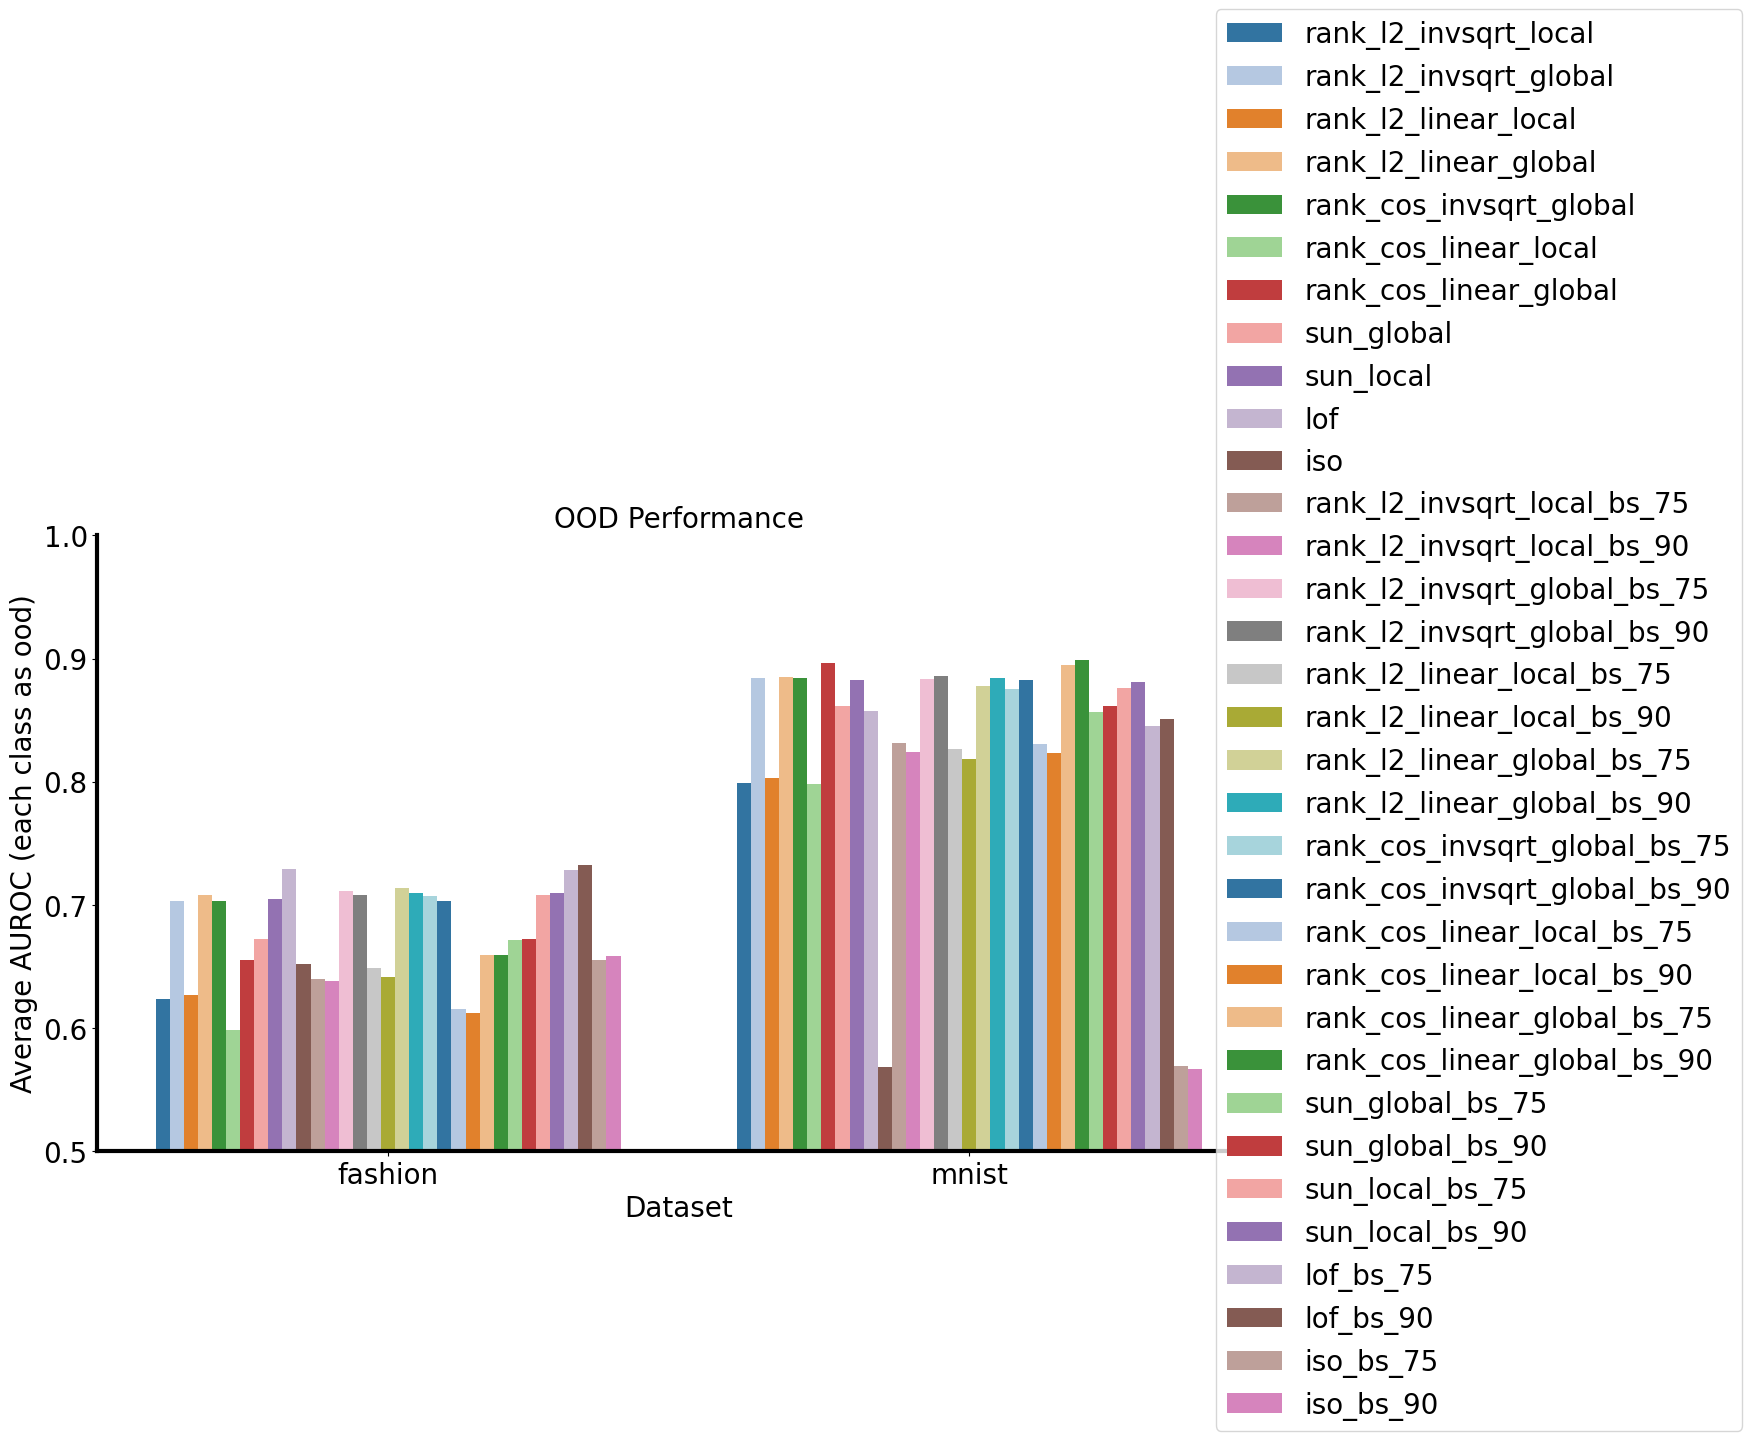

In [16]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.barplot(df[df["ood class"] == "Average"], x="dataset", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance", fontsize=20)
ax.set_xlabel("Dataset", fontsize=20)
ax.set_ylabel("Average AUROC (each class as ood)", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.95, 0.7), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

/tmp/ipykernel_1108628/3647365757.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


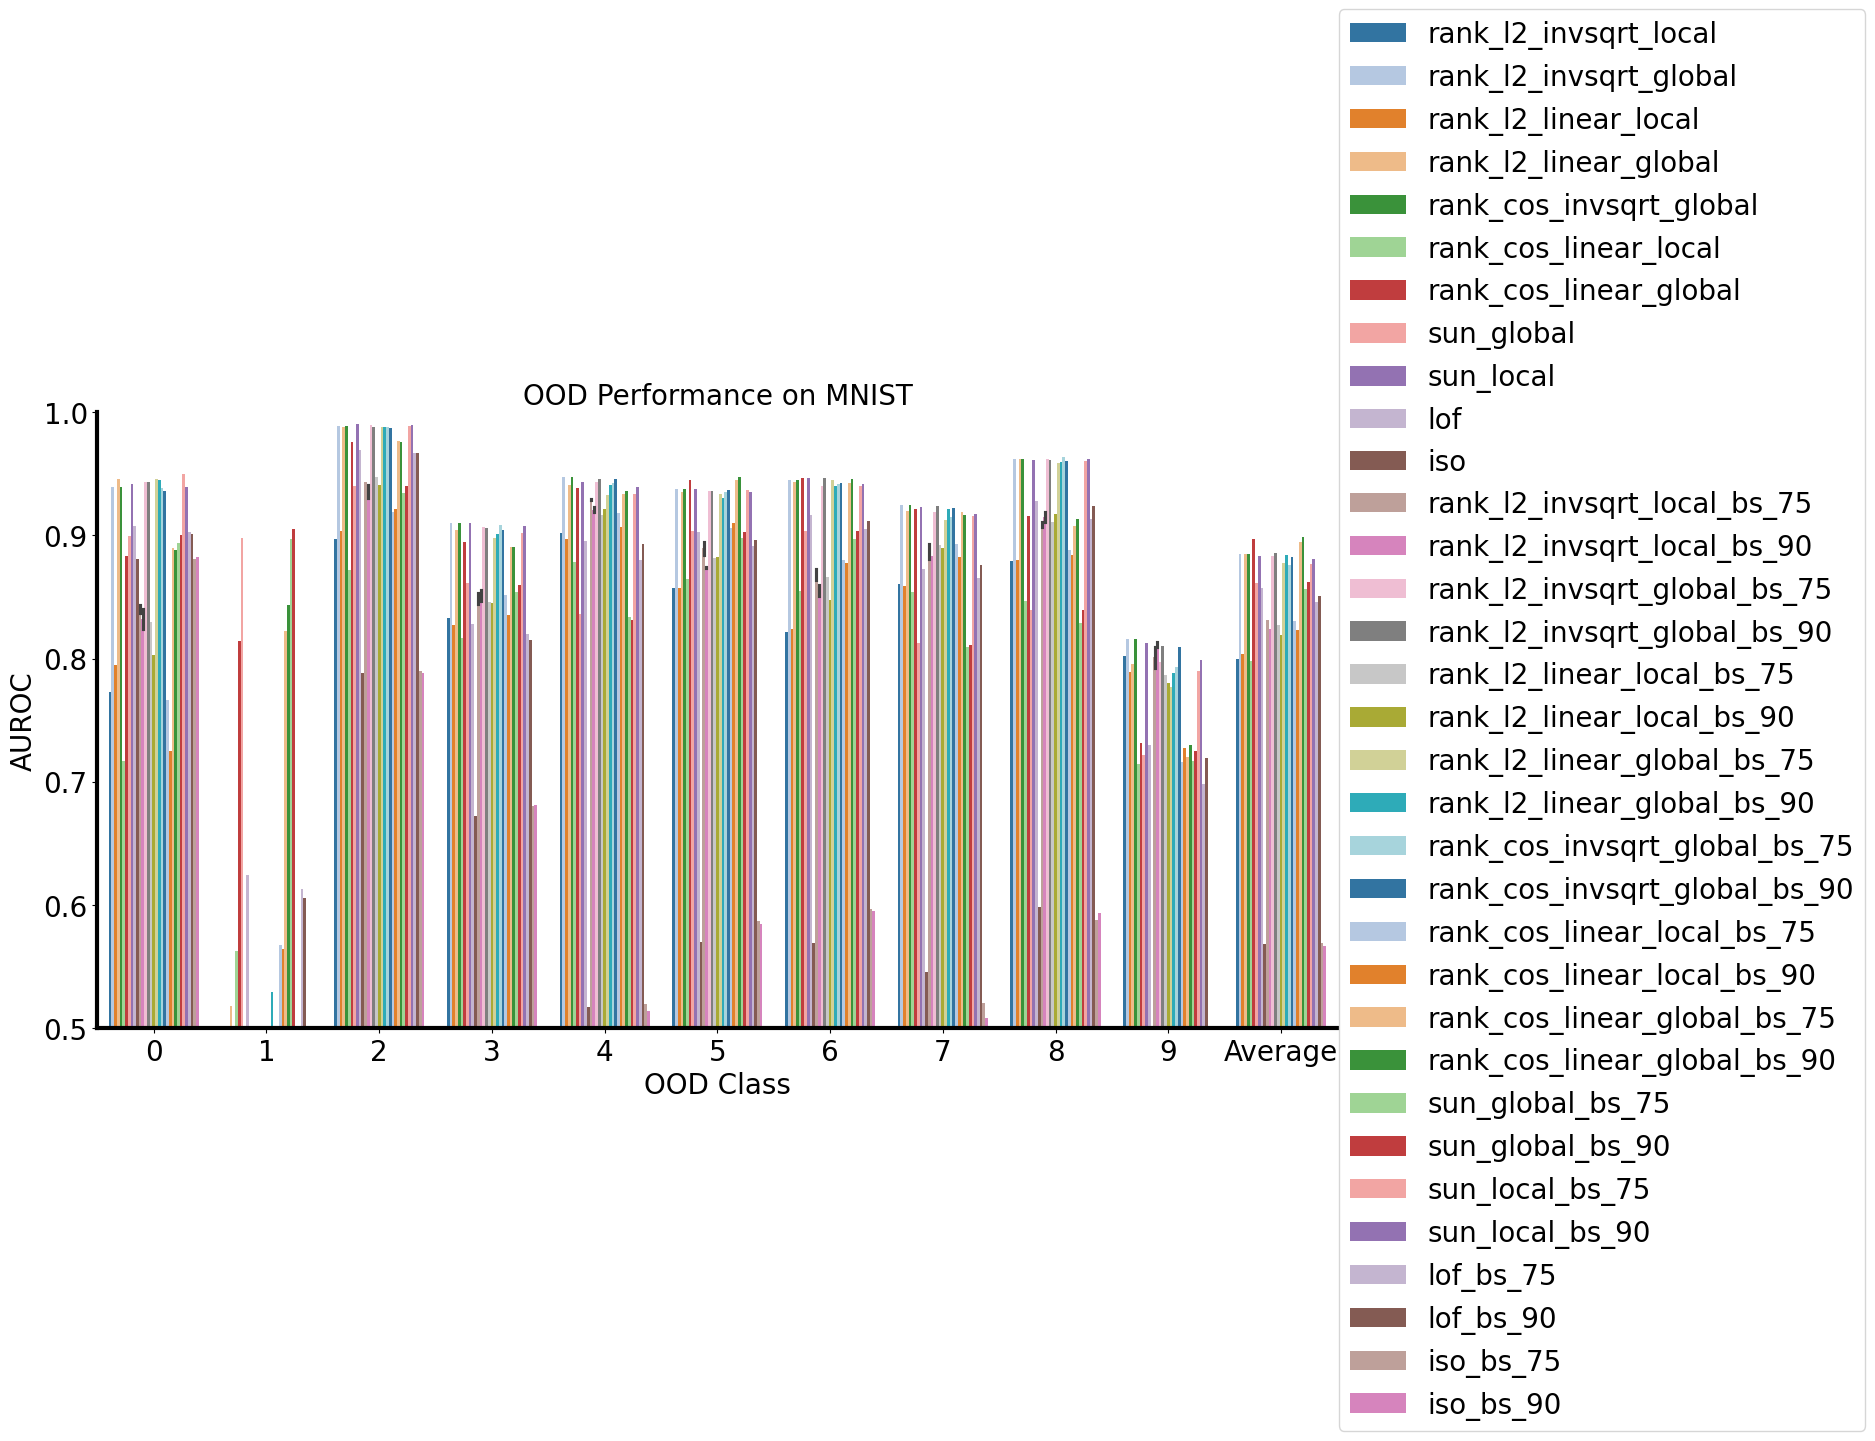

In [17]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "mnist"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.99, 0.5), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

/tmp/ipykernel_1108628/3693944799.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


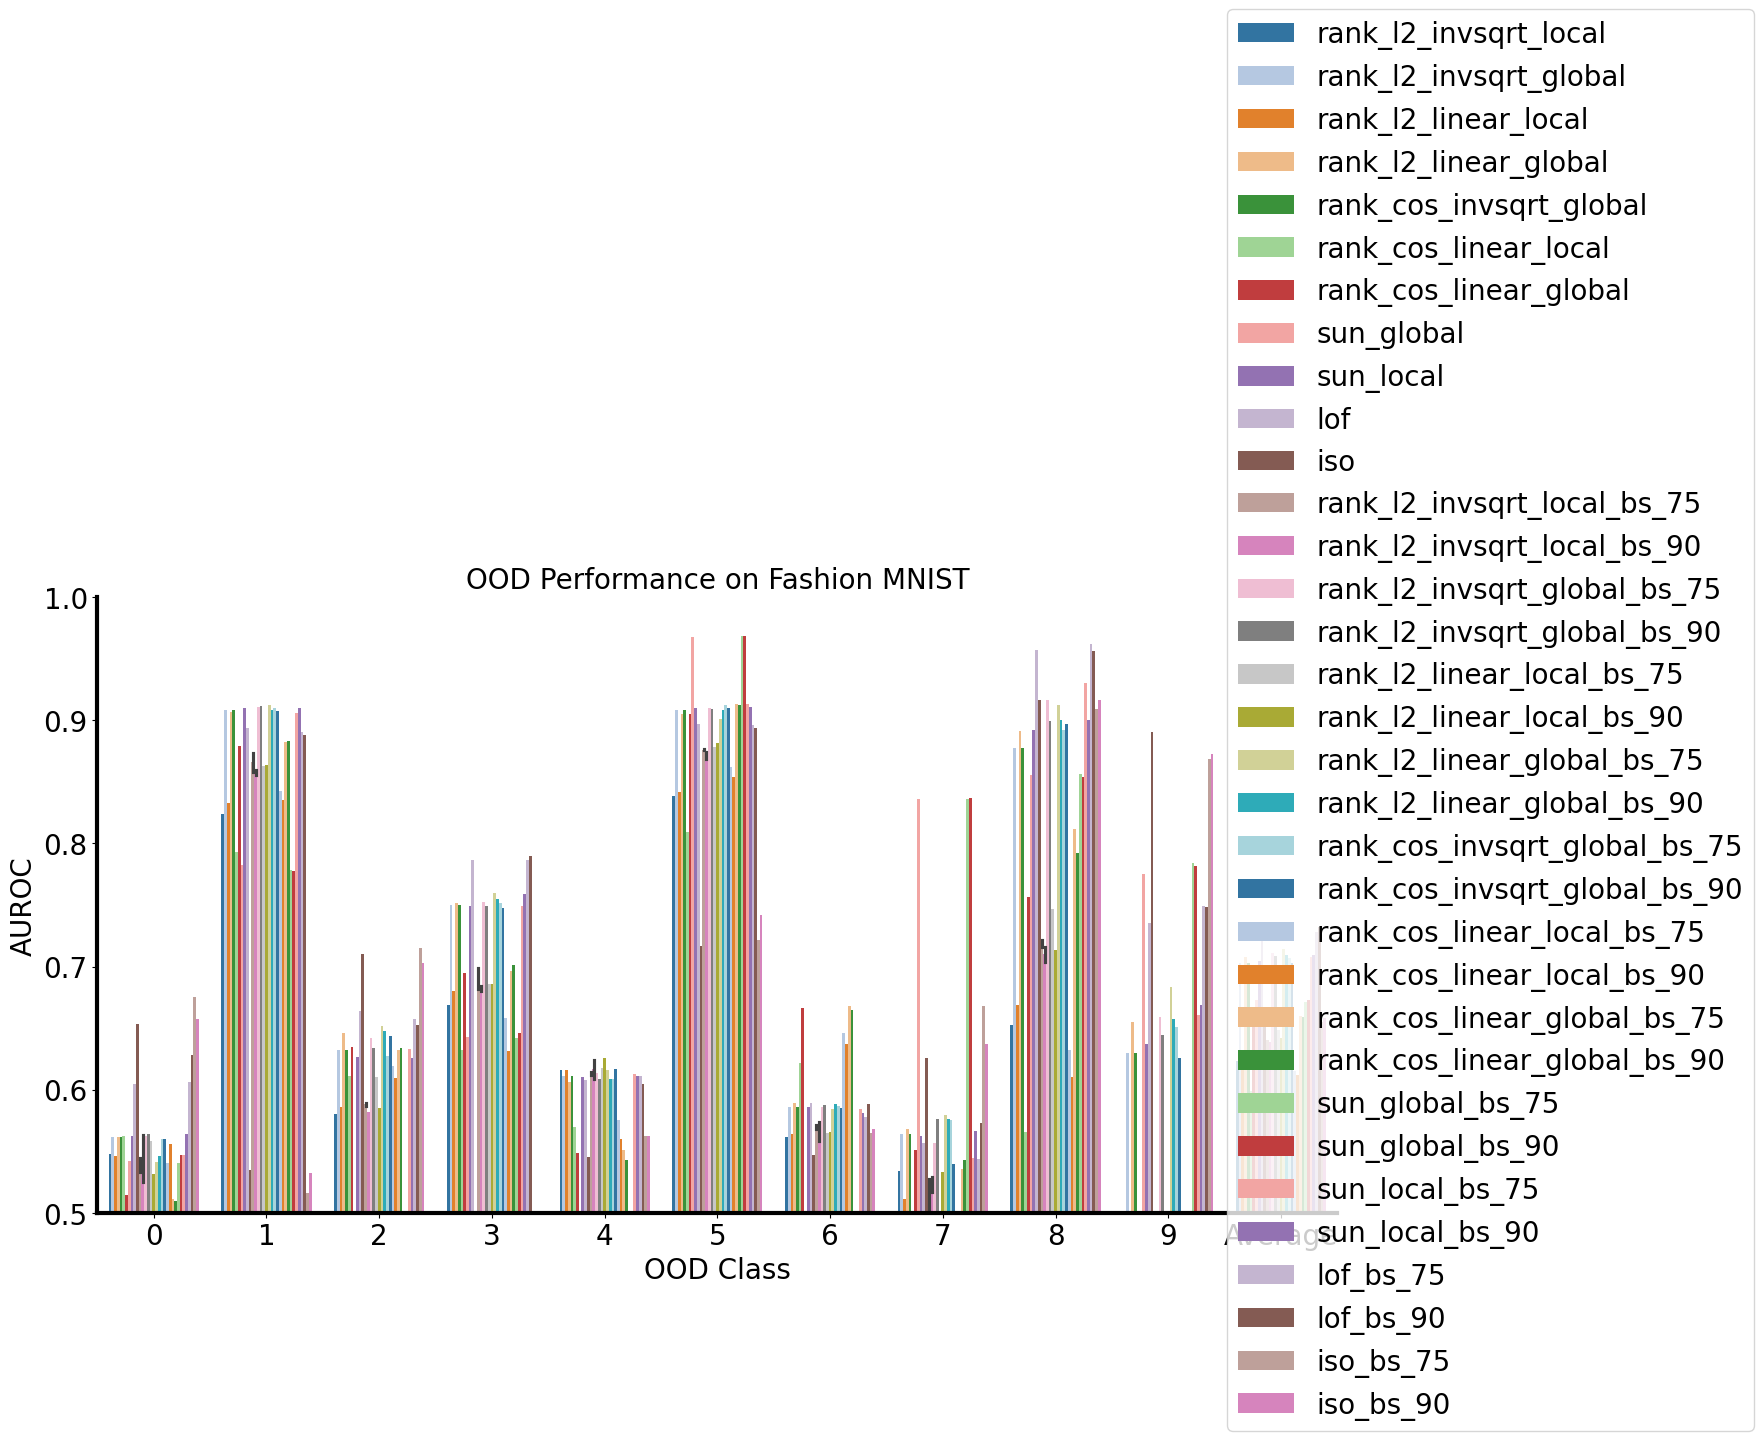

In [18]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "fashion"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on Fashion MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.9, 0.8), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()